In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import torch
from torch import nn
import os, random


def reset_random_seeds():
    os.environ['PYTHONHASHSEED']=str(2)
    torch.manual_seed(2)
    np.random.seed(2)
    random.seed(2)
    torch.cuda.manual_seed(2)
    torch.cuda.manual_seed_all(2)


df_train = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/train.csv")
df_test = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/trec_6/test.csv")

split = len(df_train)

df = pd.concat([df_train,df_test])
input_col = 'text'
output_col = "label-fine"

reset_random_seeds()

In [2]:
X = df[input_col].tolist()
Y = df[output_col].tolist()

xtrain,xtest = X[:split],X[split:]
ytrain,ytest = Y[:split],Y[split:]

In [3]:
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, TensorDataset

name = "google/electra-small-discriminator"

tokenizer = AutoTokenizer.from_pretrained(name)

BATCH = 8

def create_batch_data(x,y,shuffle=True,batch=32):
    x_ = tokenizer(x, return_tensors="pt",max_length=256,truncation=True,padding=True)
    y_ = torch.tensor(y)
    dataset = TensorDataset(x_["input_ids"], x_["attention_mask"], y_)
    data = DataLoader(dataset, batch_size=batch, shuffle=shuffle)
    return data

train = create_batch_data(xtrain,ytrain,batch=BATCH)
test = create_batch_data(xtest,ytest,shuffle=False,batch=BATCH * 2)

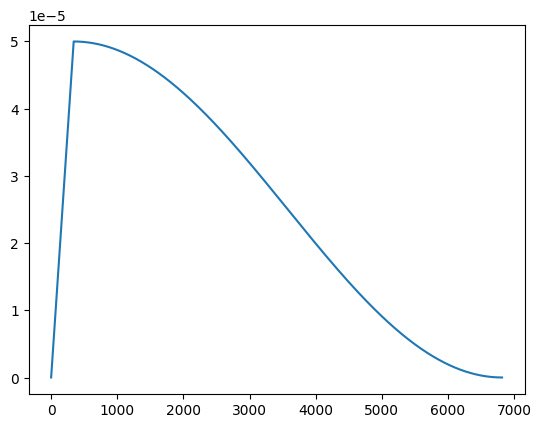

In [4]:
from cosine_lr_scheduler import CosineLRScheduler
import matplotlib.pyplot as plt

PEAK_LR = 5e-5
END_LR = 1e-8
INIT_LR = 1e-8
WARMUP_RATE = 0.05
EPOCHS = 10
TOTAL_STEPS = len(train) * EPOCHS

lr_scheduler = CosineLRScheduler(TOTAL_STEPS,peak_lr=PEAK_LR,min_lr=END_LR,
                                 init_lr=INIT_LR,warmup_rate=WARMUP_RATE)

plt.plot([lr_scheduler(i) for i in range(1,TOTAL_STEPS+1)])

In [5]:
class GeometricPooling(nn.Module):
    
    def __init__(self,temp=1):
        super().__init__()
        self.score = None
        self.temp = temp
    
    def forward(self,x,mask,sim_only=False,norm_only=False):
        
        if norm_only:
            score = torch.norm(x,dim=-1)

        elif sim_only:
            mean_vec = (x * mask[:,:,torch.newaxis]).sum(1)
            mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
            mean_vec = mean_vec[:,torch.newaxis,:]
            score = torch.cosine_similarity(mean_vec,x,dim=-1)
            
        elif (not sim_only) and (not norm_only):
            mean_vec = (x * mask[:,:,torch.newaxis]).sum(1)
            mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
            mean_vec = mean_vec[:,torch.newaxis,:]
            mean_vec = mean_vec.transpose(1,2)
            score = torch.matmul(x,mean_vec).squeeze(-1)
            
        score = torch.where(mask==0,-1e8,score)
        score = torch.softmax(score,dim=-1).unsqueeze(-1)
        return torch.sum(x * score,dim=1)
            
            
        
        

In [6]:
from torchinfo import summary


class Classifier(nn.Module):
    
    def __init__(self,dim=256,n_classes=1,sim_only=False,norm_only=False):
        super().__init__()
        self.electra = AutoModel.from_pretrained("google/electra-small-discriminator")
        self.cls_head = nn.Linear(dim,n_classes)
        
        self.sim_only = sim_only
        self.norm_only = norm_only
        self.pooling = GeometricPooling()
        
    def forward(self,x,return_pool=False):
        ids,mask = x
        x = self.electra(input_ids=ids,attention_mask=mask)
        x = x['last_hidden_state']
        x = self.pooling(x,mask=mask,norm_only=self.norm_only,sim_only=self.sim_only)
        if return_pool:
            return x
        x = self.cls_head(x)
        return x
    

reset_random_seeds()


n_classes = len(set(Y))
model = Classifier(n_classes=n_classes)
print(summary(model))
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

Layer (type:depth-idx)                                       Param #
Classifier                                                   --
├─ElectraModel: 1-1                                          --
│    └─ElectraEmbeddings: 2-1                                --
│    │    └─Embedding: 3-1                                   3,906,816
│    │    └─Embedding: 3-2                                   65,536
│    │    └─Embedding: 3-3                                   256
│    │    └─LayerNorm: 3-4                                   256
│    │    └─Dropout: 3-5                                     --
│    └─Linear: 2-2                                           33,024
│    └─ElectraEncoder: 2-3                                   --
│    │    └─ModuleList: 3-6                                  9,477,120
├─Linear: 1-2                                                12,079
├─GeometricPooling: 1-3                                      --
Total params: 13,495,087
Trainable params: 13,495,087
Non-trainable par

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics_dict(y_true, y_pred):
    
    is_standard_binary = len(set(y_true)) <= 2 and set(y_true).issubset({0, 1})
    avg = 'binary' if is_standard_binary else 'weighted'
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=avg, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=avg, zero_division=0)
    }

metrics = {"sim_and_norm":None,"norm_only":None,"sim_only":None}



In [8]:
from tqdm.auto import tqdm


def train_model(data,model,EPOCHS,file='saved_weights.pt'):

    global losses
    
    opt = torch.optim.AdamW(model.parameters(),weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()

    train,test = data

    losses = {'train':[],'valid':[]}
    
    step = 1

    for e in range(1,EPOCHS + 1):

        print(f"{e}/{EPOCHS}")
        print(f"Learning Rate = {lr_scheduler(step)}")

        loss = 0
        model.train()

        for i,batch in enumerate(tqdm(train),1):

            lr = lr_scheduler(step)
            opt.param_groups[0]['lr'] = lr

            opt.zero_grad()

            ids,mask,y = batch
            ids = ids.to(device)
            mask = mask.to(device)
            y = y.to(device)
            y = y.long()
            pred = model([ids,mask])
            batch_loss = loss_fn(pred,y)
            batch_loss.backward()
            opt.step()

            loss += batch_loss.item()
            
            step += 1

        loss = round(loss / len(train),4)
        losses['train'].append(loss)
        train_loss = loss

        model.eval()
        loss = 0

        with torch.no_grad():

            for i,batch in enumerate(tqdm(test)):

                ids,mask,y = batch
                ids = ids.to(device)
                mask = mask.to(device)
                y = y.to(device)
                y = y.long() 
                pred = model([ids,mask])
                batch_loss = loss_fn(pred,y)
                loss += batch_loss.item()
        
        print(f'Train Loss = {train_loss}')
        loss = round(loss / len(test),4)
        print(f"Val Loss = {loss}")


        if e == 1 or loss < min(losses['valid']):
            torch.save(model.state_dict(),file)
            print("--weights saved")

        losses['valid'].append(loss)
        print('--------------------------------------')
        print()

In [9]:
reset_random_seeds()

model = Classifier(n_classes=n_classes)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_model((train,test),model,EPOCHS=EPOCHS,file='sim_and_norm.pt')

state_dict = torch.load('sim_and_norm.pt', map_location=device)
model.load_state_dict(state_dict)

1/10
Learning Rate = 1e-08


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 2.3553
Val Loss = 1.2802
--weights saved
--------------------------------------

2/10
Learning Rate = 4.965710302874277e-05


  0%|          | 0/682 [00:00<?, ?it/s]

...

Train Loss = 0.0741
Val Loss = 0.5668
--------------------------------------

10/10
Learning Rate = 1.3603655341837609e-06


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 0.0651
Val Loss = 0.565
--------------------------------------



<All keys matched successfully>

In [10]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

with torch.no_grad():

    for x,mask, _ in test:
        x = x.to(device)
        mask = mask.to(device)
        pred = model([x,mask])
        pred = torch.softmax(pred,-1)
        pred = torch.argmax(pred,1).cpu().numpy()
        preds.extend(pred)

#     for x,mask, _ in test:
#         x = x.to(device)
#         mask = mask.to(device)
#         pred = model([x,mask])
#         pred = torch.sigmoid(pred) 
#         pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
#         if pred.ndim == 0:
#             preds.append(pred.item())
#         else:
#             preds.extend(pred)

print(classification_report(ytest,preds,zero_division=0))
print(f1_score(ytest,preds,average='macro'))  
# print(f1_score(ytest,preds))  

metrics['sim_and_norm'] = get_metrics_dict(ytest,preds)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           2       0.87      0.81      0.84        16
           3       0.70      0.88      0.78         8
           4       1.00      1.00      1.00        55
           5       0.83      0.83      0.83         6
           6       0.25      1.00      0.40         1
           7       0.95      0.97      0.96       123
           8       0.98      1.00      0.99        47
           9       1.00      1.00      1.00         6
          10       0.67      1.00      0.80         2
          11       0.88      1.00      0.93         7
          12       0.91      1.00      0.95        10
          13       1.00      1.00      1.00         9
          14       0.84      0.84      0.84        74
          17       1.00      0.75      0.86         4
          18       1.00      1.00      1.00         3
          19       1.00      1.00      1.00        10
          20       0.62    

In [11]:
reset_random_seeds()

model = Classifier(n_classes=n_classes,sim_only=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_model((train,test),model,EPOCHS=EPOCHS,file='sim_only.pt')

state_dict = torch.load('sim_only.pt', map_location=device)
model.load_state_dict(state_dict)

1/10
Learning Rate = 1e-08


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 2.3215
Val Loss = 1.2338
--weights saved
--------------------------------------

2/10
Learning Rate = 4.965710302874277e-05


  0%|          | 0/682 [00:00<?, ?it/s]

...

Train Loss = 0.0747
Val Loss = 0.5153
--------------------------------------

10/10
Learning Rate = 1.3603655341837609e-06


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 0.0653
Val Loss = 0.51
--------------------------------------



<All keys matched successfully>

In [12]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

with torch.no_grad():

    for x,mask, _ in test:
        x = x.to(device)
        mask = mask.to(device)
        pred = model([x,mask])
        pred = torch.softmax(pred,-1)
        pred = torch.argmax(pred,1).cpu().numpy()
        preds.extend(pred)

#     for x,mask, _ in test:
#         x = x.to(device)
#         mask = mask.to(device)
#         pred = model([x,mask])
#         pred = torch.sigmoid(pred) 
#         pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
#         if pred.ndim == 0:
#             preds.append(pred.item())
#         else:
#             preds.extend(pred)

print(classification_report(ytest,preds,zero_division=0))
print(f1_score(ytest,preds,average='macro'))  
# print(f1_score(ytest,preds))  

metrics['sim_only'] = get_metrics_dict(ytest,preds)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           2       0.81      0.81      0.81        16
           3       0.88      0.88      0.88         8
           4       1.00      1.00      1.00        55
           5       0.71      0.83      0.77         6
           6       0.00      0.00      0.00         1
           7       0.95      0.98      0.97       123
           8       0.98      1.00      0.99        47
           9       1.00      1.00      1.00         6
          10       0.67      1.00      0.80         2
          11       1.00      1.00      1.00         7
          12       0.90      0.90      0.90        10
          13       1.00      1.00      1.00         9
          14       0.86      0.84      0.85        74
          17       1.00      0.75      0.86         4
          18       1.00      1.00      1.00         3
          19       1.00      1.00      1.00        10
          20       0.62    

In [13]:
reset_random_seeds()

model = Classifier(n_classes=n_classes,norm_only=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_model((train,test),model,EPOCHS=EPOCHS,file='norm_only.pt')

state_dict = torch.load('norm_only.pt', map_location=device)
model.load_state_dict(state_dict)

1/10
Learning Rate = 1e-08


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 2.4094
Val Loss = 1.3176
--weights saved
--------------------------------------

2/10
Learning Rate = 4.965710302874277e-05


  0%|          | 0/682 [00:00<?, ?it/s]

...

Train Loss = 0.0658
Val Loss = 0.4733
--------------------------------------

10/10
Learning Rate = 1.3603655341837609e-06


  0%|          | 0/682 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss = 0.058
Val Loss = 0.4744
--------------------------------------



<All keys matched successfully>

In [14]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

with torch.no_grad():

    for x,mask, _ in test:
        x = x.to(device)
        mask = mask.to(device)
        pred = model([x,mask])
        pred = torch.softmax(pred,-1)
        pred = torch.argmax(pred,1).cpu().numpy()
        preds.extend(pred)

#     for x,mask, _ in test:
#         x = x.to(device)
#         mask = mask.to(device)
#         pred = model([x,mask])
#         pred = torch.sigmoid(pred) 
#         pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
#         if pred.ndim == 0:
#             preds.append(pred.item())
#         else:
#             preds.extend(pred)

print(classification_report(ytest,preds,zero_division=0))
print(f1_score(ytest,preds,average='macro'))  
# print(f1_score(ytest,preds))  

metrics['norm_only'] = get_metrics_dict(ytest,preds)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           2       0.86      0.75      0.80        16
           3       0.78      0.88      0.82         8
           4       0.98      1.00      0.99        55
           5       0.83      0.83      0.83         6
           6       0.00      0.00      0.00         1
           7       0.96      0.98      0.97       123
           8       1.00      1.00      1.00        47
           9       1.00      1.00      1.00         6
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         7
          12       0.82      0.90      0.86        10
          13       0.75      1.00      0.86         9
          14       0.85      0.82      0.84        74
          17       1.00      0.75      0.86         4
          18       1.00      1.00      1.00         3
          19       0.91      1.00      0.95        10
          20       0.56    

In [15]:
import json


with open("ablation1_metrics.json",'w') as f:
    json.dump(metrics,f)

In [16]:
metrics

{'sim_and_norm': {'accuracy': 0.906,
  'precision': 0.9152488181818181,
  'recall': 0.906,
  'f1': 0.9035420023666204},
 'norm_only': {'accuracy': 0.908,
  'precision': 0.9108886435786436,
  'recall': 0.908,
  'f1': 0.906412047211684},
 'sim_only': {'accuracy': 0.914,
  'precision': 0.9128854924384452,
  'recall': 0.914,
  'f1': 0.9100376396297295}}

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


def load_model(name,sim_only=False,norm_only=False):
    model = Classifier(n_classes=n_classes,norm_only=norm_only,sim_only=sim_only)
    model = model.to('cuda')
    state_dict = torch.load(f'{name}.pt', map_location='cuda')
    model.load_state_dict(state_dict)
    return model

model0 = load_model('sim_and_norm')
model1 = load_model('sim_only',sim_only=True)
model2 = load_model('norm_only',norm_only=True)


def get_pooled_vectors(model,test):
    
    with torch.no_grad():

        vectors = []

        for x,mask, _ in test:
            x = x.to('cuda')
            mask = mask.to('cuda')
            pool_vec = model([x,mask],return_pool=True)
            pool_vec = pool_vec.cpu().numpy()
            vectors.extend(pool_vec)
        
        vectors = np.array(vectors,dtype=np.float32)
        
        return vectors

reset_random_seeds()    
    
vectors0 = get_pooled_vectors(model0,test)
vectors1 = get_pooled_vectors(model1,test)
vectors2 = get_pooled_vectors(model2,test)


def cluster_eval(embeddings,true_labels,name='',classes=len(set(ytrain))):
    kmeans = KMeans(n_clusters=classes, n_init=10, random_state=42)
    cluster_preds = kmeans.fit_predict(embeddings)
    ari = adjusted_rand_score(true_labels, cluster_preds)
    print(f"Clustering ARI against True Sentiment: {ari:.4f} ({name})")
    return ari,name

cluster_eval_metrics = {}

ari,name = cluster_eval(vectors0,ytest,'sim_and_norm')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors1,ytest,'sim_only')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors2,ytest,'norm_only')
cluster_eval_metrics[name] = ari

with open("ablation1_cluster_metrics.json",'w') as f:
    json.dump(cluster_eval_metrics,f)

Clustering ARI against True Sentiment: 0.5788 (sim_and_norm)
Clustering ARI against True Sentiment: 0.6585 (sim_only)
Clustering ARI against True Sentiment: 0.6413 (norm_only)
